<a href="https://colab.research.google.com/github/bishalkshah70-art/AI-and-Ml-/blob/main/knn_classifiaction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [85]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve
)

In [86]:
df = pd.read_csv("/content/knn_classification_dataset1_671931f9-0d0e-476c-8a6b-798fa4912842_268917_.csv")

In [87]:
print("="*60)
print(df.head())

   Age  Annual_Income  Credit_Score  Loan_Amount  Employment_Years  \
0   15          53571           825        56370                 7   
1   26          21337           682       123557                 6   
2   19          45581           743       186122                 8   
3   -9          11538           747        36599                 4   
4   35          65455           850        82712                12   

   Loan_Approved  
0              1  
1              0  
2              0  
3              1  
4              1  


In [88]:
print("\nDataset Shape")
print(df.shape)


Dataset Shape
(500, 6)


In [89]:
if "Age" in df.columns:
    median_age = df[df["Age"] > 0]["Age"].median()
    df["Age"] = df["Age"].apply(lambda x: median_age if x <= 0 else x)



In [90]:
print(df.isnull().sum())

Age                 0
Annual_Income       0
Credit_Score        0
Loan_Amount         0
Employment_Years    0
Loan_Approved       0
dtype: int64


In [91]:
x = df.drop("Loan_Approved", axis=1)
y = df["Loan_Amount"]
print("\nFeature Columns")
print(x.columns.tolist())


Feature Columns
['Age', 'Annual_Income', 'Credit_Score', 'Loan_Amount', 'Employment_Years']


In [92]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.20,
    random_state=42
)


In [93]:
print("\nTraining Shape:", x_train.shape)
print("Testing Shape:", x_test.shape)


Training Shape: (400, 5)
Testing Shape: (100, 5)


In [94]:
scaler = StandardScaler()

# Fit on training data and transform it
x_train_scaled = scaler.fit_transform(x_train)

# Transform the test data using the same scaler
x_test_scaled = scaler.transform(x_test)

In [95]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

error_rates = []
accuracy_scores = []

k_range = range(1, 21, 2)

for k in k_range:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(x_train_scaled, y_train)

    pred = model.predict(x_test_scaled)

    accuracy = accuracy_score(y_test, pred)
    error = 1 - accuracy

    accuracy_scores.append(accuracy)
    error_rates.append(error)

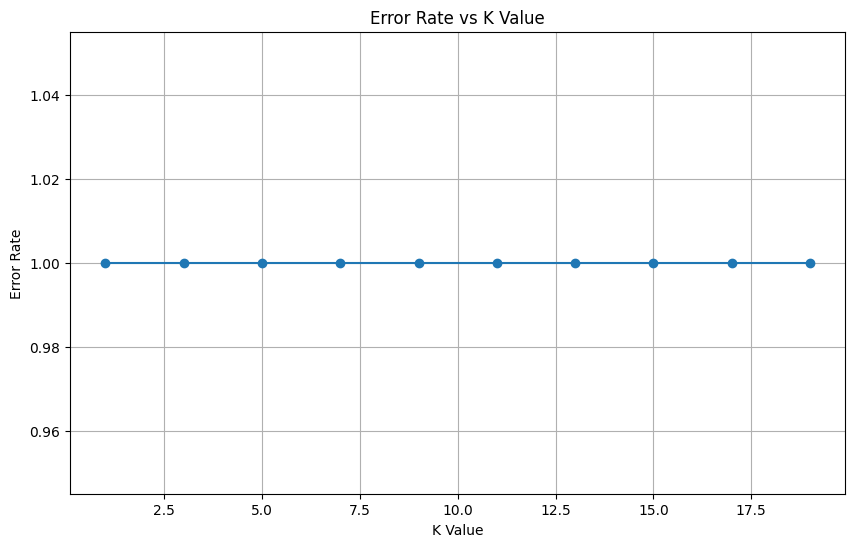

In [96]:
#plot k vs error rtae
plt.figure(figsize=(10,6))
plt.plot(
k_range,
error_rates,
marker="o",
linestyle="-"
)


plt.title("Error Rate vs K Value")
plt.xlabel("K Value")
plt.ylabel("Error Rate")
plt.grid(True)
plt.savefig("knn_error_rate.png")
plt.show()

In [97]:
# choose best k
best_k = k_range[np.argmin(error_rates)]
print("\nBest K Found:", best_k)


Best K Found: 1


In [98]:
final_knn =KNeighborsClassifier(n_neighbors=best_k, metric="euclidean")

In [99]:
# train final model

final_knn.fit(
x_train_scaled,
y_train
)


y_pred= final_knn.predict(
    x_test_scaled
)

In [100]:
# model evaluation
print("Final Model Performance")
print("="*60)
print(
    "\nAccuracy",
    round(
        accuracy_score(y_test, y_pred),
        4
    ) * 100
)
print("\nClassification Report")
print(
    classification_report(
        y_test,
        y_pred
    )
)

Final Model Performance

Accuracy 0.0

Classification Report
              precision    recall  f1-score   support

       56370       0.00      0.00      0.00       1.0
       72081       0.00      0.00      0.00       0.0
       76744       0.00      0.00      0.00       1.0
       79469       0.00      0.00      0.00       1.0
       81282       0.00      0.00      0.00       1.0
       82338       0.00      0.00      0.00       0.0
       82684       0.00      0.00      0.00       1.0
       86703       0.00      0.00      0.00       1.0
       87098       0.00      0.00      0.00       0.0
       89249       0.00      0.00      0.00       1.0
       89867       0.00      0.00      0.00       0.0
       91397       0.00      0.00      0.00       1.0
       92308       0.00      0.00      0.00       0.0
       94520       0.00      0.00      0.00       0.0
       96843       0.00      0.00      0.00       1.0
       97014       0.00      0.00      0.00       1.0
       97861       0

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

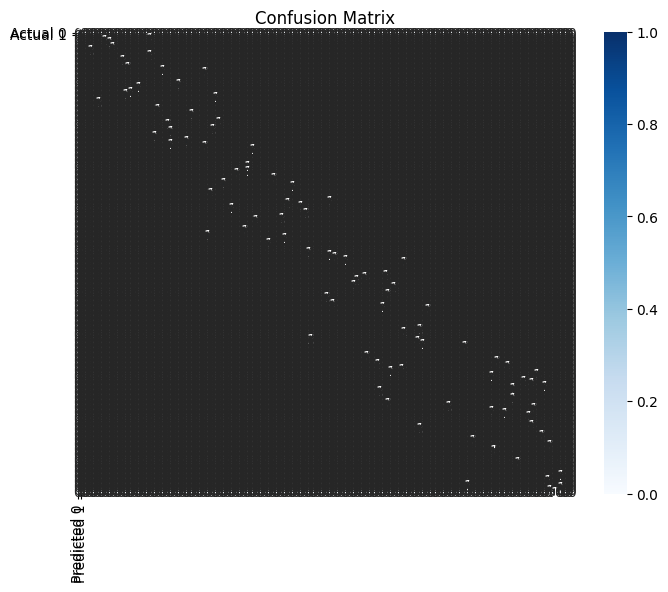

In [101]:
# comfusion matrix

cm = confusion_matrix(
  y_test,
  y_pred
)


plt.figure(figsize=(8, 6))
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted 0", "Predicted 1"],
    yticklabels=["Actual 0", "Actual 1"]
    #xticklabels=["Rejected", "Approved"],
    #yticklabels=["Rejected", "Approved"]
)

plt.show()

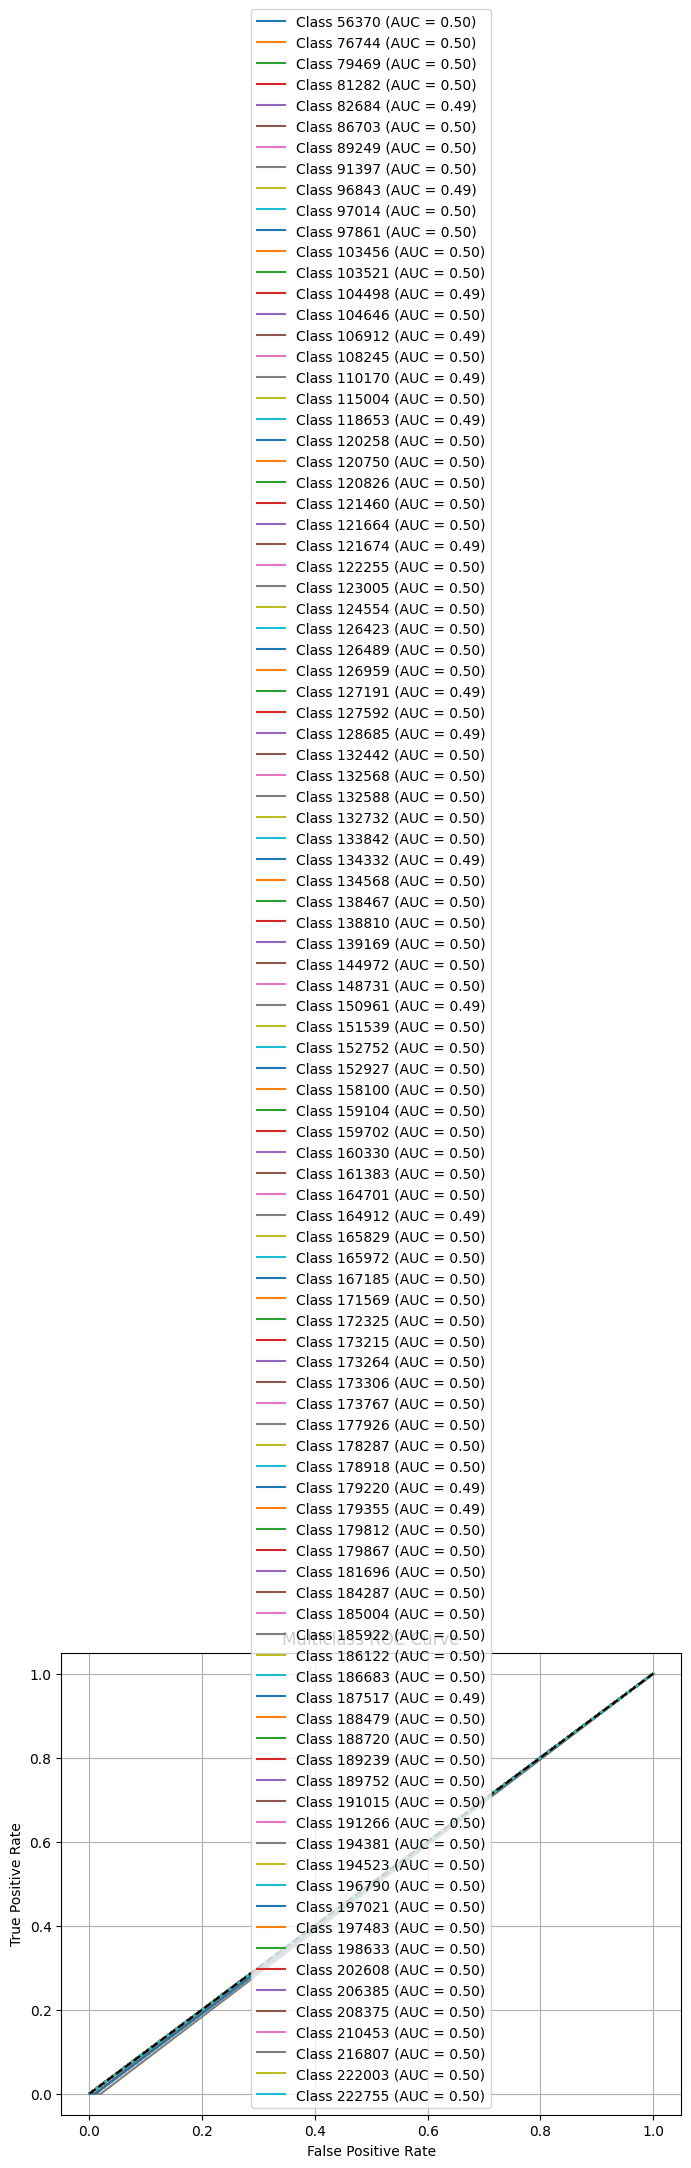

In [102]:


classes = np.unique(y_test)

# Convert y_test to binary matrix
y_test_bin = label_binarize(y_test, classes=classes)

# Predicted probabilities
y_prob = final_knn.predict_proba(x_test_scaled)

plt.figure(figsize=(8, 6))

for i in range(len(classes)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {classes[i]} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

In [103]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# Binarize the labels
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

# Predict probabilities
y_prob = final_knn.predict_proba(x_test_scaled)

# ROC for class 0
fpr, tpr, _ = roc_curve(y_test_bin[:, 0], y_prob[:, 0])
roc_auc = auc(fpr, tpr)

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


In [104]:
from sklearn.metrics import roc_curve, auc

# Predict probabilities for the positive class
y_prob = final_knn.predict_proba(x_test_scaled)[:, 1]

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Compute AUC
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"ROC Curve (AUC = {roc_auc:.2f})",
    linewidth=2
)

# Random Guess Line
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Guess")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.legend(loc="lower right")
plt.grid(True)

plt.show()

ValueError: multiclass format is not supported